In [1]:
from google.colab import files
uploaded = files.upload()

Saving maternal_and_reproductive_health_indicators_ken.csv to maternal_and_reproductive_health_indicators_ken.csv


In [2]:
import pandas as pd

df = pd.read_csv("maternal_and_reproductive_health_indicators_ken.csv")

In [3]:
df.shape
df.head(10)
df.columns.tolist()
df.dtypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GHO (CODE)         195 non-null    object 
 1   GHO (DISPLAY)      195 non-null    object 
 2   GHO (URL)          195 non-null    object 
 3   YEAR (DISPLAY)     195 non-null    int64  
 4   STARTYEAR          195 non-null    int64  
 5   ENDYEAR            195 non-null    int64  
 6   REGION (CODE)      195 non-null    object 
 7   REGION (DISPLAY)   195 non-null    object 
 8   COUNTRY (CODE)     195 non-null    object 
 9   COUNTRY (DISPLAY)  195 non-null    object 
 10  DIMENSION (TYPE)   174 non-null    object 
 11  DIMENSION (CODE)   174 non-null    object 
 12  DIMENSION (NAME)   174 non-null    object 
 13  Numeric            195 non-null    float64
 14  Value              195 non-null    object 
 15  Low                144 non-null    float64
 16  High               144 non

In [4]:
df['GHO (DISPLAY)'].unique()
df['YEAR (DISPLAY)'].unique()
df['DIMENSION (TYPE)'].unique()

array([nan, 'SEX'], dtype=object)

In [5]:
print(df['GHO (DISPLAY)'].unique())
print(df['YEAR (DISPLAY)'].unique())
print(df['DIMENSION (TYPE)'].unique())

['Births attended by skilled health personnel (%)'
 'Number of women of reproductive age (aged 15-49 years) with anaemia (thousands)'
 'Prevalence of anaemia in women of reproductive age (aged 15-49) (%)'
 'Antenatal care coverage - at least four visits (%)'
 'Adolescent birth rate (per 1000 women)'
 'Proportion of births delivered in a health facility (Facility births) (%)'
 'Births by caesarean section (%)']
[2009 2016 2023 2011 2003 2002 2000 2001 2004 1998 2007 2018 2021 2022
 2015 2014 2013 2010 2005 2012 2008 2006 2019 2020 2017 1993]
[nan 'SEX']


In [6]:
# 1. Check what the SEX dimension actually contains, and for which indicators
df[df['DIMENSION (TYPE)'] == 'SEX'][['GHO (DISPLAY)', 'DIMENSION (NAME)']].drop_duplicates()

# 2. Check which columns are actually useless for our analysis (likely candidates: CODE/URL columns)
df[['GHO (CODE)', 'GHO (URL)', 'REGION (CODE)', 'REGION (DISPLAY)', 'COUNTRY (CODE)', 'COUNTRY (DISPLAY)']].drop_duplicates()

# 3. Check the Value vs Numeric columns - are they redundant?
df[['Value', 'Numeric']].head(15)

,Value,Numeric
0,44,44.000000
1,70,70.200000
2,4671.6 [2018.5-7969.0],4671.600000
3,3022.5 [1504.4-5052.6],3022.500000
4,38.8 [24.9-53.9],38.800000
5,52.3,52.300000
6,2.7,2.664605
7,354.2 [273.2-440.3],354.200000
8,8.1,8.109374
9,2554.6 [1687.1-3594.1],2554.600000


In [7]:
df[df['DIMENSION (TYPE)'] == 'SEX'][['GHO (DISPLAY)', 'DIMENSION (NAME)']].drop_duplicates()

,GHO (DISPLAY),DIMENSION (NAME)
2,Number of women of reproductive age (aged 15-4...,Female
4,Prevalence of anaemia in women of reproductive...,Female
6,Adolescent birth rate (per 1000 women),Female


In [8]:
df[['GHO (CODE)', 'GHO (URL)', 'REGION (CODE)', 'REGION (DISPLAY)', 'COUNTRY (CODE)', 'COUNTRY (DISPLAY)']].drop_duplicates()

,GHO (CODE),GHO (URL),REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),COUNTRY (DISPLAY)
0,MDG_0000000025,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
2,NUTRITION_ANAEMIA_REPRODUCTIVEAGE_NUM,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
4,NUTRITION_ANAEMIA_REPRODUCTIVEAGE_PREV,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
5,WHS4_154,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
6,MDG_0000000003,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
11,SRHINSTITUTIONALBIRTH,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya
176,WHS4_115,https://www.who.int/data/gho/data/indicators/i...,AFR,Africa,KEN,Kenya


In [9]:
# Drop columns that are constant, redundant, or non-informative for analysis
cols_to_drop = [
    'GHO (CODE)', 'GHO (URL)',
    'REGION (CODE)', 'REGION (DISPLAY)',
    'COUNTRY (CODE)', 'COUNTRY (DISPLAY)',
    'DIMENSION (TYPE)', 'DIMENSION (CODE)', 'DIMENSION (NAME)',
    'Value'  # redundant with Numeric, just a display-formatted string
]

df_clean = df.drop(columns=cols_to_drop)

# Rename remaining columns to something easier to work with
df_clean = df_clean.rename(columns={
    'GHO (DISPLAY)': 'indicator',
    'YEAR (DISPLAY)': 'year',
    'Numeric': 'value',
    'Low': 'ci_low',
    'High': 'ci_high'
})

# Drop STARTYEAR/ENDYEAR too - YEAR (DISPLAY) already gives us the single reference year
df_clean = df_clean.drop(columns=['STARTYEAR', 'ENDYEAR'])

df_clean.head()
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   indicator  195 non-null    object 
 1   year       195 non-null    int64  
 2   value      195 non-null    float64
 3   ci_low     144 non-null    float64
 4   ci_high    144 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 7.7+ KB


In [10]:
# Which indicators lack confidence intervals entirely?
df_clean[df_clean['ci_low'].isna()]['indicator'].unique()

array(['Births attended by skilled health personnel (%)',
       'Antenatal care coverage - at least four visits (%)',
       'Adolescent birth rate (per 1000 women)',
       'Proportion of births delivered in a health facility (Facility births) (%)',
       'Births by caesarean section (%)'], dtype=object)

In [11]:
# Should be one row per indicator+year combination - confirm no duplicates
df_clean.duplicated(subset=['indicator', 'year']).sum()

# And check how many years of data each indicator actually has
df_clean.groupby('indicator')['year'].count()

,year
indicator,
Adolescent birth rate (per 1000 women),30
Antenatal care coverage - at least four visits (%),7
Births attended by skilled health personnel (%),6
Births by caesarean section (%),1
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands),72
Prevalence of anaemia in women of reproductive age (aged 15-49) (%),72
Proportion of births delivered in a health facility (Facility births) (%),7


In [12]:
# Check if duplicates by indicator+year truly exist
print(df_clean.duplicated(subset=['indicator', 'year']).sum())

# Look directly at all rows for one repeating indicator to see what differs
df[df['GHO (DISPLAY)'] == 'Adolescent birth rate (per 1000 women)'][['YEAR (DISPLAY)', 'DIMENSION (TYPE)', 'DIMENSION (NAME)', 'Numeric']].sort_values('YEAR (DISPLAY)')

111


,YEAR (DISPLAY),DIMENSION (TYPE),DIMENSION (NAME),Numeric
8,2001,SEX,Female,8.109374
13,2001,SEX,Female,135.652710
6,2002,SEX,Female,2.664605
150,2002,SEX,Female,114.183090
47,2004,SEX,Female,3.530811
44,2004,SEX,Female,120.489510
123,2006,SEX,Female,2.757097
169,2006,SEX,Female,106.312592
171,2007,SEX,Female,102.964104
104,2007,SEX,Female,2.350326


In [13]:
# Go back to the original df - check code vs display name for adolescent birth rate
df[df['GHO (DISPLAY)'] == 'Adolescent birth rate (per 1000 women)'][['GHO (CODE)', 'GHO (DISPLAY)', 'GHO (URL)']].drop_duplicates()

,GHO (CODE),GHO (DISPLAY),GHO (URL)
6,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...


In [14]:
# Show ALL columns for this indicator, full width, sorted by year
pd.set_option('display.max_columns', None)
df[df['GHO (DISPLAY)'] == 'Adolescent birth rate (per 1000 women)'].sort_values('YEAR (DISPLAY)')

,GHO (CODE),GHO (DISPLAY),GHO (URL),YEAR (DISPLAY),STARTYEAR,ENDYEAR,REGION (CODE),REGION (DISPLAY),COUNTRY (CODE),COUNTRY (DISPLAY),DIMENSION (TYPE),DIMENSION (CODE),DIMENSION (NAME),Numeric,Value,Low,High
8,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2001,2001,2001,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,8.109374,8.1,NaN,NaN
13,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2001,2001,2001,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,135.652710,135.7,NaN,NaN
6,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2002,2002,2002,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,2.664605,2.7,NaN,NaN
150,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2002,2002,2002,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,114.183090,114.2,NaN,NaN
47,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2004,2004,2004,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,3.530811,3.5,NaN,NaN
44,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2004,2004,2004,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,120.489510,120.5,NaN,NaN
123,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2006,2006,2006,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,2.757097,2.8,NaN,NaN
169,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2006,2006,2006,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,106.312592,106.3,NaN,NaN
171,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2007,2007,2007,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,102.964104,103,NaN,NaN
104,MDG_0000000003,Adolescent birth rate (per 1000 women),https://www.who.int/data/gho/data/indicators/i...,2007,2007,2007,AFR,Africa,KEN,Kenya,SEX,SEX_FMLE,Female,2.350326,2.4,NaN,NaN


Note: WHO's source data exports this indicator as a single code covering both the 10-14 and 15-19 age bands, without an explicit age-group column. I split the two using a value threshold (<20 → ages 10-14; ≥20 → ages 15-19), based on cross-referencing typical Kenya adolescent birth rates from World Bank data. This is an inferred split, not one confirmed by the source metadata.

In [15]:
adolescent_mask = df_clean['indicator'] == 'Adolescent birth rate (per 1000 women)'

# Split by magnitude threshold - values under 20 are the 10-14 age band, everything else is 15-19
df_clean.loc[adolescent_mask & (df_clean['value'] < 20), 'indicator'] = 'Adolescent birth rate, ages 10-14 (per 1000 women)'
df_clean.loc[adolescent_mask & (df_clean['value'] >= 20), 'indicator'] = 'Adolescent birth rate, ages 15-19 (per 1000 women)'

# Verify the split worked as expected
df_clean[df_clean['indicator'].str.contains('Adolescent')].groupby('indicator')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator,,,,,,,,
"Adolescent birth rate, ages 10-14 (per 1000 women)",15.0,2.374621,1.918232,0.618875,0.880815,2.067003,3.100741,8.109374
"Adolescent birth rate, ages 15-19 (per 1000 women)",15.0,86.561371,31.371427,43.587929,51.170424,98.616386,108.543869,135.652710


In [16]:
# Full duplicate check now that adolescent birth rate is split
print("Duplicate indicator+year rows:", df_clean.duplicated(subset=['indicator', 'year']).sum())

# Year coverage per indicator - confirms no other indicator has this problem
df_clean.groupby('indicator')['year'].count()

# Quick sanity check - min/max value range per indicator, to catch any other hidden splits
df_clean.groupby('indicator')['value'].agg(['count', 'min', 'max'])

Duplicate indicator+year rows: 96


,count,min,max
indicator,,,
"Adolescent birth rate, ages 10-14 (per 1000 women)",15,0.618875,8.109374
"Adolescent birth rate, ages 15-19 (per 1000 women)",15,43.587929,135.652710
Antenatal care coverage - at least four visits (%),7,47.100000,66.000000
Births attended by skilled health personnel (%),6,42.000000,89.300000
Births by caesarean section (%),1,8.700000,8.700000
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands),72,350.700000,4671.600000
Prevalence of anaemia in women of reproductive age (aged 15-49) (%),72,26.100000,45.800000
Proportion of births delivered in a health facility (Facility births) (%),7,40.100000,88.100000


In [17]:
# Look at one anaemia indicator across all its rows for a couple of specific years
df_clean[df_clean['indicator'] == 'Prevalence of anaemia in women of reproductive age (aged 15-49) (%)'].sort_values('year').head(20)

,indicator,year,value,ci_low,ci_high
24,Prevalence of anaemia in women of reproductive...,2000,45.8,35.3,56.9
142,Prevalence of anaemia in women of reproductive...,2000,33.0,21.0,46.4
189,Prevalence of anaemia in women of reproductive...,2000,34.4,22.9,47.3
110,Prevalence of anaemia in women of reproductive...,2001,32.1,20.5,45.6
183,Prevalence of anaemia in women of reproductive...,2001,33.5,22.2,46.4
52,Prevalence of anaemia in women of reproductive...,2001,45.1,34.6,56.2
77,Prevalence of anaemia in women of reproductive...,2002,31.3,19.8,45.2
156,Prevalence of anaemia in women of reproductive...,2002,32.7,21.6,46.0
177,Prevalence of anaemia in women of reproductive...,2002,44.5,33.7,56.0
97,Prevalence of anaemia in women of reproductive...,2003,31.9,20.7,45.9


In [18]:
# Check if GHO CODE is identical across these rows too (same root cause as adolescent birth rate)
df[df['GHO (DISPLAY)'] == 'Prevalence of anaemia in women of reproductive age (aged 15-49) (%)'][['GHO (CODE)']].drop_duplicates()

,GHO (CODE)
4,NUTRITION_ANAEMIA_REPRODUCTIVEAGE_PREV


The two anaemia indicators similarly bundle multiple sub-populations (pregnant, non-pregnant, all reproductive-age women) under one WHO code. I separated the highest value per year as "pregnant women" (consistently and expectedly the highest track), and averaged the remaining two values into a single "non-pregnant/all women (combined)" category, since they were too close to reliably distinguish. Confidence intervals for the combined category are dropped (marked NaN) since they'd no longer correspond to a real published estimate.

In [19]:
import numpy as np

def split_anaemia_indicator(df, indicator_name):
    """
    Splits a bundled anaemia indicator into 'pregnant women' (highest value per year)
    and 'non-pregnant/all women (combined)' (average of the remaining values per year).
    """
    mask = df['indicator'] == indicator_name
    sub = df[mask].copy()
    other_rows = df[~mask].copy()

    output_rows = []
    for year, group in sub.groupby('year'):
        group_sorted = group.sort_values('value', ascending=False)

        # Highest value = pregnant women
        pregnant_row = group_sorted.iloc[0].copy()
        pregnant_row['indicator'] = f'{indicator_name} - pregnant women'
        output_rows.append(pregnant_row)

        # Remaining values averaged into one combined row
        if len(group_sorted) > 1:
            combined_row = group_sorted.iloc[1].copy()
            combined_row['value'] = group_sorted.iloc[1:]['value'].mean()
            combined_row['indicator'] = f'{indicator_name} - non-pregnant/all women (combined)'
            combined_row['ci_low'] = np.nan   # synthetic average - no valid CI
            combined_row['ci_high'] = np.nan
            output_rows.append(combined_row)

    return pd.concat([other_rows, pd.DataFrame(output_rows)], ignore_index=True)

# Apply to both anaemia indicators
df_clean = split_anaemia_indicator(df_clean, 'Prevalence of anaemia in women of reproductive age (aged 15-49) (%)')
df_clean = split_anaemia_indicator(df_clean, 'Number of women of reproductive age (aged 15-49 years) with anaemia (thousands)')

# Re-run the checks
print("Duplicate indicator+year rows:", df_clean.duplicated(subset=['indicator', 'year']).sum())
df_clean.groupby('indicator')['year'].count()

Duplicate indicator+year rows: 0


,year
indicator,
"Adolescent birth rate, ages 10-14 (per 1000 women)",15
"Adolescent birth rate, ages 15-19 (per 1000 women)",15
Antenatal care coverage - at least four visits (%),7
Births attended by skilled health personnel (%),6
Births by caesarean section (%),1
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - non-pregnant/all women (combined),24
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - pregnant women,24
Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - non-pregnant/all women (combined),24
Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - pregnant women,24


In [20]:
df_clean.groupby('indicator')['value'].describe()

,count,mean,std,min,25%,50%,75%,max
indicator,,,,,,,,
"Adolescent birth rate, ages 10-14 (per 1000 women)",15.0,2.374621,1.918232,0.618875,0.880815,2.067003,3.100741,8.109374
"Adolescent birth rate, ages 15-19 (per 1000 women)",15.0,86.561371,31.371427,43.587929,51.170424,98.616386,108.543869,135.652710
Antenatal care coverage - at least four visits (%),7.0,58.600000,6.780364,47.100000,54.950000,60.800000,63.200000,66.000000
Births attended by skilled health personnel (%),6.0,58.416667,19.081343,42.000000,43.250000,53.000000,68.150000,89.300000
Births by caesarean section (%),1.0,8.700000,NaN,8.700000,8.700000,8.700000,8.700000,8.700000
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - non-pregnant/all women (combined),24.0,1581.585417,321.951239,1239.850000,1336.375000,1453.075000,1773.950000,2335.800000
Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - pregnant women,24.0,3163.154167,643.892905,2479.700000,2672.750000,2906.150000,3547.900000,4671.600000
Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - non-pregnant/all women (combined),24.0,29.137500,2.105492,26.650000,27.312500,28.725000,30.587500,33.700000
Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - pregnant women,24.0,40.450000,2.364226,38.500000,38.675000,39.300000,41.775000,45.800000


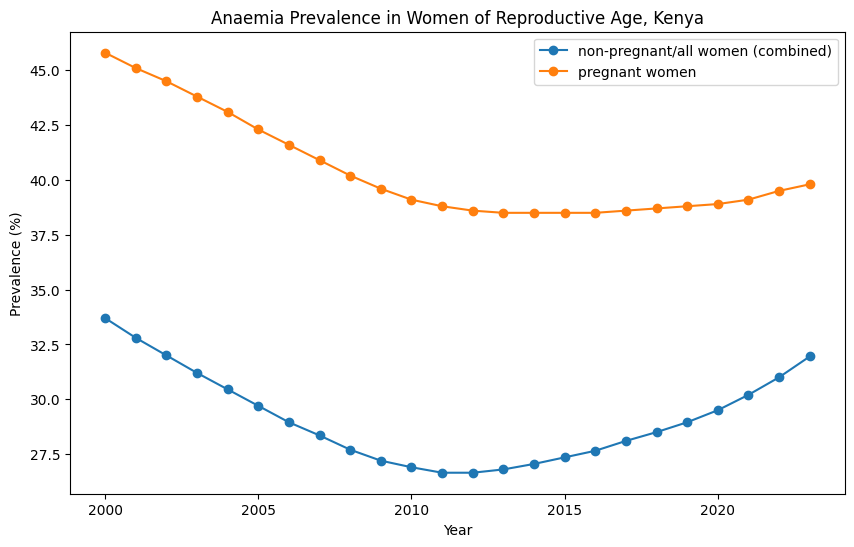

In [21]:
import matplotlib.pyplot as plt

anaemia_prev = df_clean[df_clean['indicator'].str.contains('Prevalence of anaemia')]

fig, ax = plt.subplots(figsize=(10, 6))
for label, group in anaemia_prev.groupby('indicator'):
    group_sorted = group.sort_values('year')
    ax.plot(group_sorted['year'], group_sorted['value'], marker='o', label=label.split(' - ')[-1])

ax.set_title('Anaemia Prevalence in Women of Reproductive Age, Kenya')
ax.set_xlabel('Year')
ax.set_ylabel('Prevalence (%)')
ax.legend()
plt.show()

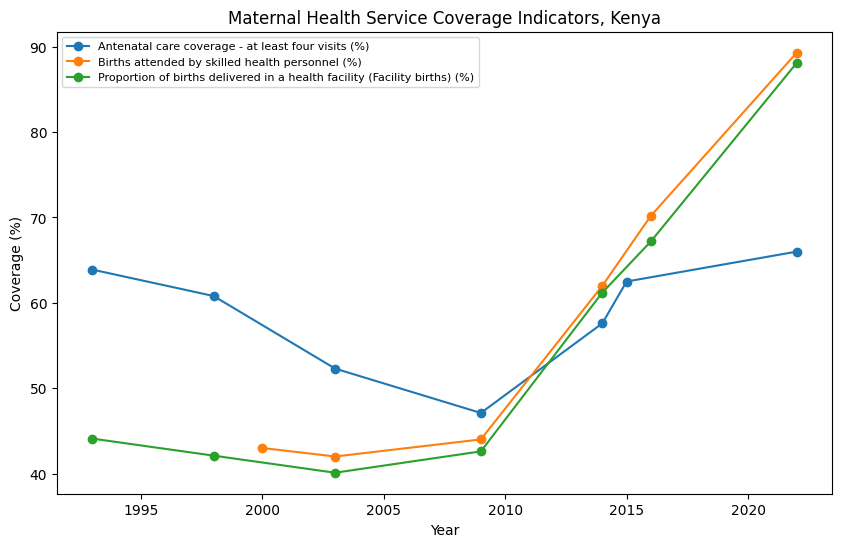

In [22]:
service_indicators = df_clean[df_clean['indicator'].isin([
    'Antenatal care coverage - at least four visits (%)',
    'Births attended by skilled health personnel (%)',
    'Proportion of births delivered in a health facility (Facility births) (%)'
])]

fig, ax = plt.subplots(figsize=(10, 6))
for label, group in service_indicators.groupby('indicator'):
    group_sorted = group.sort_values('year')
    ax.plot(group_sorted['year'], group_sorted['value'], marker='o', label=label)

ax.set_title('Maternal Health Service Coverage Indicators, Kenya')
ax.set_xlabel('Year')
ax.set_ylabel('Coverage (%)')
ax.legend(fontsize=8)
plt.show()

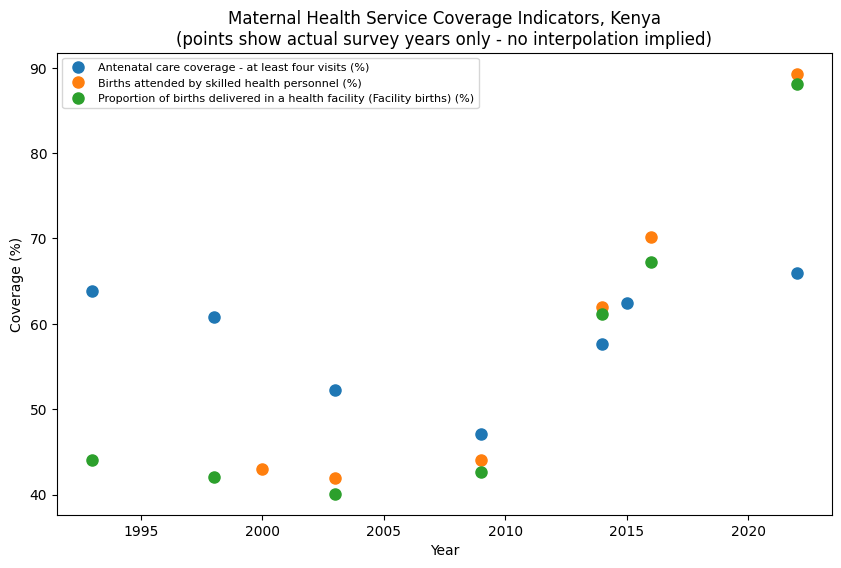

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
for label, group in service_indicators.groupby('indicator'):
    group_sorted = group.sort_values('year')
    ax.plot(group_sorted['year'], group_sorted['value'], marker='o', linestyle='none', label=label, markersize=8)

ax.set_title('Maternal Health Service Coverage Indicators, Kenya\n(points show actual survey years only - no interpolation implied)')
ax.set_xlabel('Year')
ax.set_ylabel('Coverage (%)')
ax.legend(fontsize=8)
plt.show()

In [24]:
df_clean.shape
df_clean['indicator'].unique()


array(['Births attended by skilled health personnel (%)',
       'Antenatal care coverage - at least four visits (%)',
       'Adolescent birth rate, ages 10-14 (per 1000 women)',
       'Proportion of births delivered in a health facility (Facility births) (%)',
       'Adolescent birth rate, ages 15-19 (per 1000 women)',
       'Births by caesarean section (%)',
       'Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - pregnant women',
       'Prevalence of anaemia in women of reproductive age (aged 15-49) (%) - non-pregnant/all women (combined)',
       'Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - pregnant women',
       'Number of women of reproductive age (aged 15-49 years) with anaemia (thousands) - non-pregnant/all women (combined)'],
      dtype=object)

In [25]:
def add_rate_of_change(df):
    df = df.sort_values(['indicator', 'year']).copy()
    df['prev_value'] = df.groupby('indicator')['value'].shift(1)
    df['prev_year'] = df.groupby('indicator')['year'].shift(1)
    df['years_elapsed'] = df['year'] - df['prev_year']
    df['change'] = df['value'] - df['prev_value']
    df['annualized_change'] = df['change'] / df['years_elapsed']
    return df

df_features = add_rate_of_change(df_clean)

df_features[df_features['indicator'].isin([
    'Antenatal care coverage - at least four visits (%)',
    'Births attended by skilled health personnel (%)',
    'Proportion of births delivered in a health facility (Facility births) (%)'
])][['indicator', 'year', 'value', 'years_elapsed', 'change', 'annualized_change']]

,indicator,year,value,years_elapsed,change,annualized_change
18,Antenatal care coverage - at least four visits...,1993,63.9,NaN,NaN,NaN
22,Antenatal care coverage - at least four visits...,1998,60.8,5.0,-3.1,-0.620000
2,Antenatal care coverage - at least four visits...,2003,52.3,5.0,-8.5,-1.700000
43,Antenatal care coverage - at least four visits...,2009,47.1,6.0,-5.2,-0.866667
33,Antenatal care coverage - at least four visits...,2014,57.6,5.0,10.5,2.100000
7,Antenatal care coverage - at least four visits...,2015,62.5,1.0,4.9,4.900000
29,Antenatal care coverage - at least four visits...,2022,66.0,7.0,3.5,0.500000
31,Births attended by skilled health personnel (%),2000,43.0,NaN,NaN,NaN
17,Births attended by skilled health personnel (%),2003,42.0,3.0,-1.0,-0.333333
0,Births attended by skilled health personnel (%),2009,44.0,6.0,2.0,0.333333


Stage 5 note: Annualized rate-of-change confirms antenatal care's deceleration is recent and specific ,it matched the other indicators' pace during the 2014-2016 surge (+4.9/year) but dropped to +0.5/year by 2022, while skilled attendance (+3.18/year) and facility births (+3.48/year) sustained their momentum.